# Credit Scoring EDA

In [47]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from scipy import stats

import warnings

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="pastel")

df = pd.read_csv('../data/data.csv')
print(f"Dataset shape: {df.shape}")

Dataset shape: (100000, 28)


In [48]:
df.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


In [49]:
print(df.describe())

       Monthly_Inhand_Salary  Num_Bank_Accounts  Num_Credit_Card  \
count           84998.000000      100000.000000     100000.00000   
mean             4194.170850          17.091280         22.47443   
std              3183.686167         117.404834        129.05741   
min               303.645417          -1.000000          0.00000   
25%              1625.568229           3.000000          4.00000   
50%              3093.745000           6.000000          5.00000   
75%              5957.448333           7.000000          7.00000   
max             15204.633333        1798.000000       1499.00000   

       Interest_Rate  Delay_from_due_date  Num_Credit_Inquiries  \
count  100000.000000        100000.000000          98035.000000   
mean       72.466040            21.068780             27.754251   
std       466.422621            14.860104            193.177339   
min         1.000000            -5.000000              0.000000   
25%         8.000000            10.000000           

## 1. Analysis of Distributions

In [50]:
def plot_numeric_distributions(df, columns):
    n_cols = 2
    n_rows = (len(columns) + 1) // 2
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
    axes = axes.flatten()
    
    for idx, col in enumerate(columns):
        sns.histplot(data=df, x=col, ax=axes[idx], kde=True, bins=30)
        axes[idx].set_title(f'Distribution of {col}')
        
    for idx in range(len(columns), len(axes)):
        axes[idx].set_visible(False)
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

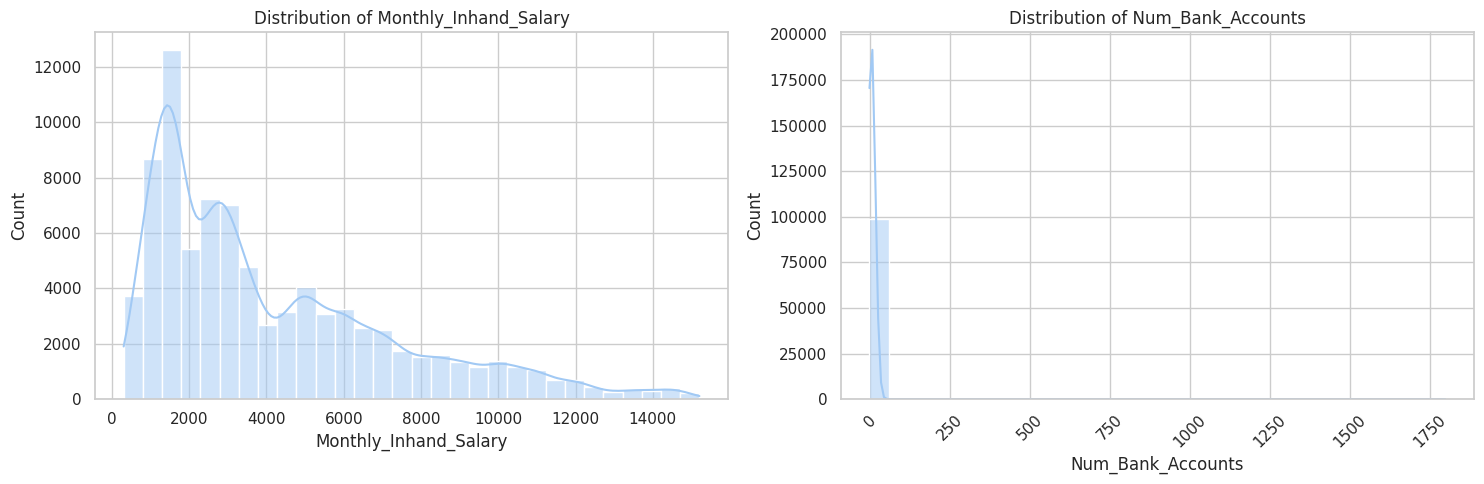

In [51]:
numeric_cols = ['Monthly_Inhand_Salary', 'Num_Bank_Accounts']
plot_numeric_distributions(df, numeric_cols)

In [52]:
def plot_categorical_distributions(df, columns):
    for col in columns:
        plt.figure(figsize=(12, 6))
        value_counts = df[col].value_counts()
        sns.barplot(x=value_counts.index, y=value_counts.values)
        plt.title(f'Distribution of {col}')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

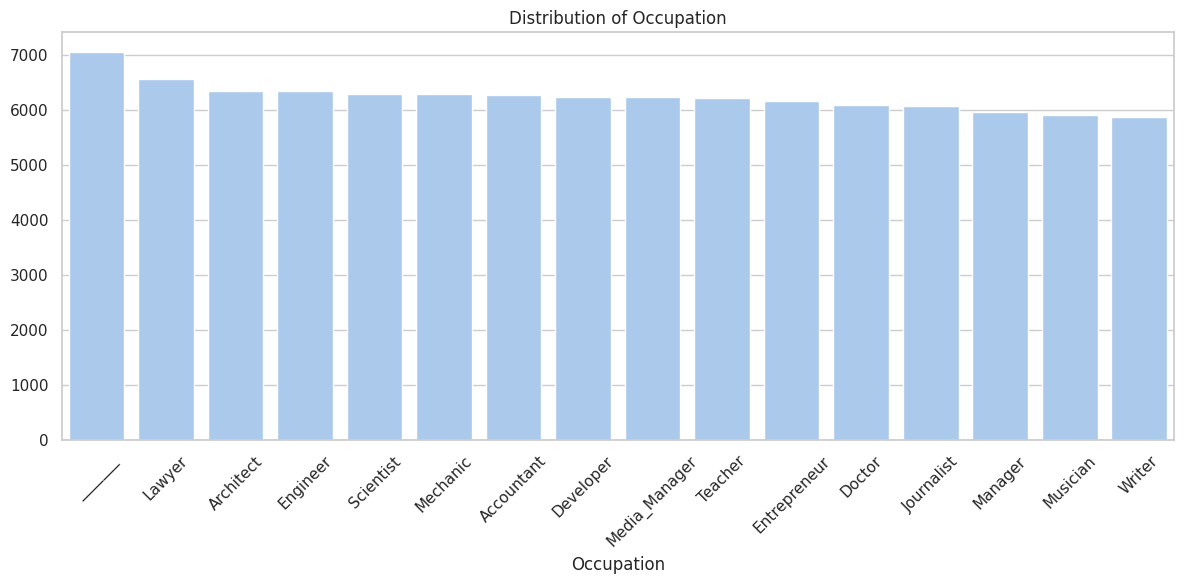

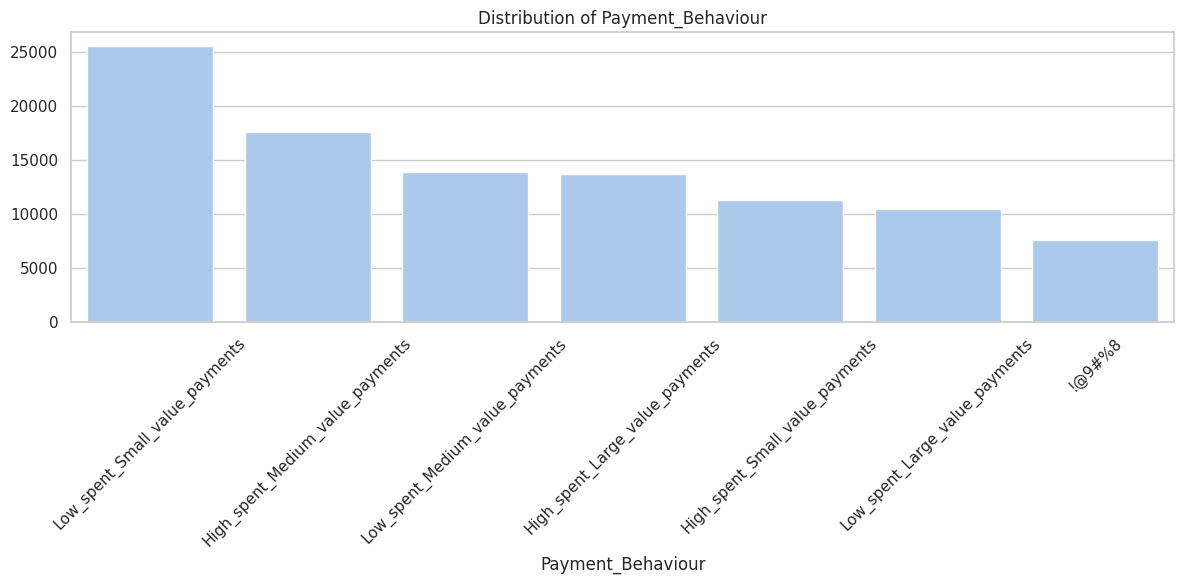

In [53]:
categorical_cols = ['Occupation', "Payment_Behaviour"]
plot_categorical_distributions(df, categorical_cols)

Target Variable Distribution

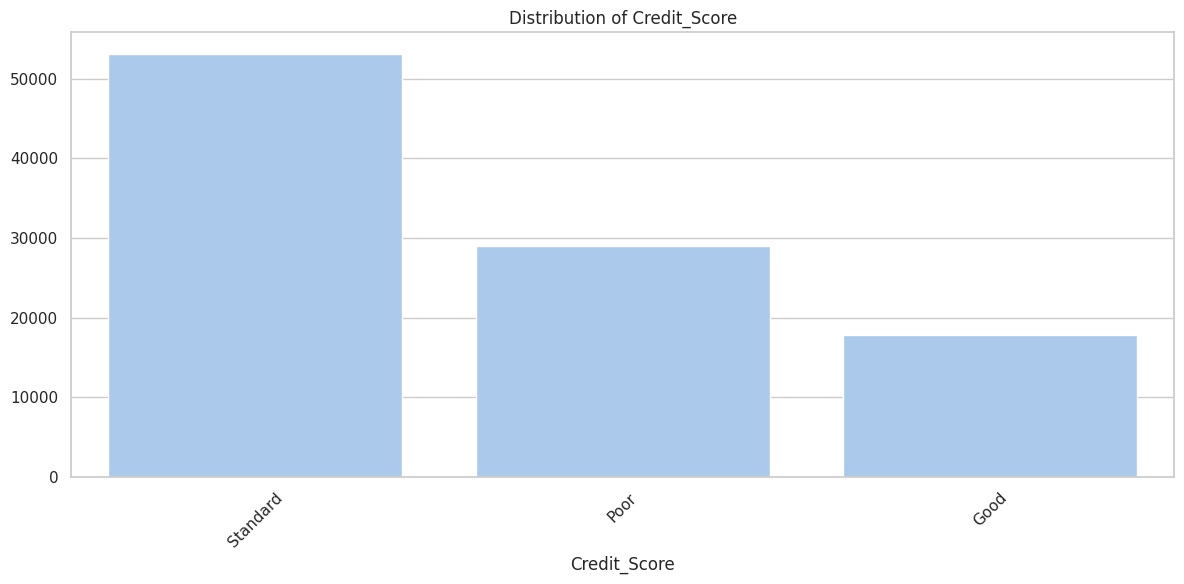

In [54]:
plot_categorical_distributions(df, ["Credit_Score"])

Additional preprocessing for specific variables

In [55]:
def convert_credit_history_to_months(df):
    def parse_age(age_str):
        if pd.isna(age_str):
            return None
            
        if "Years and" in age_str:
            years = int(age_str.split("Years and")[0].strip())
            months = int(age_str.split("Years and")[1].split("Months")[0].strip())
            return years * 12 + months
            
        elif "Years" in age_str:
            years = int(age_str.split("Years")[0].strip())
            return years * 12
            
        elif "Months" in age_str:
            months = int(age_str.split("Months")[0].strip())
            return months
            
        return None

    df['Credit_History_Months'] = df['Credit_History_Age'].apply(parse_age)

In [56]:
convert_credit_history_to_months(df)

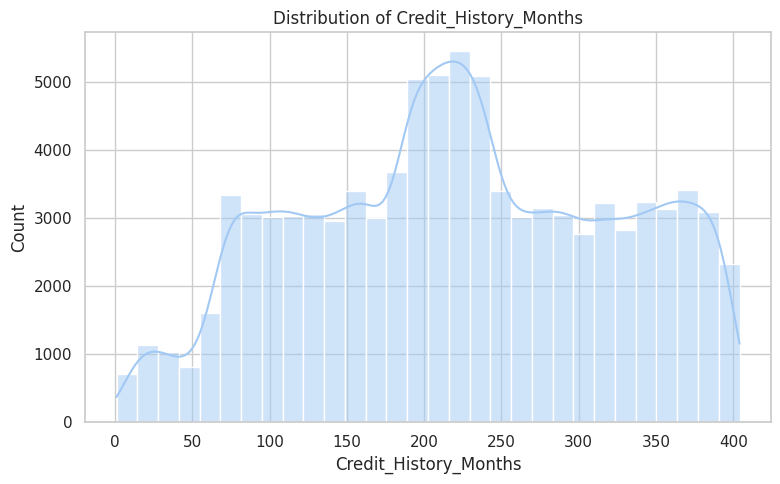

In [57]:
plot_numeric_distributions(df, ["Credit_History_Months"])

## 2. Analysis of Missing Values

In [58]:
def analyze_missing_values(df):
    missing_values = df.isnull().sum()
    missing_percentage = (missing_values / len(df)) * 100
    
    missing_df = pd.DataFrame({
        'Missing Values': missing_values,
        'Percentage': missing_percentage
    })
    
    plt.figure(figsize=(12, 6))
    sns.barplot(x=missing_df.index, y='Percentage', data=missing_df)
    plt.title('Percentage of Missing Values by Column')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    return missing_df

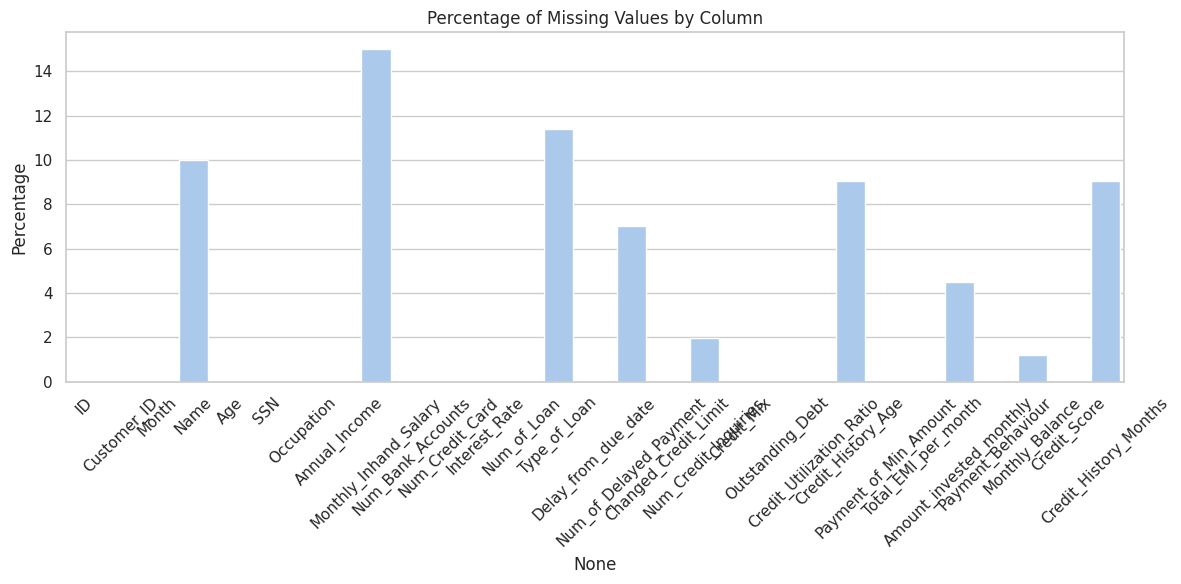

                          Missing Values  Percentage
ID                                     0       0.000
Customer_ID                            0       0.000
Month                                  0       0.000
Name                                9985       9.985
Age                                    0       0.000
SSN                                    0       0.000
Occupation                             0       0.000
Annual_Income                          0       0.000
Monthly_Inhand_Salary              15002      15.002
Num_Bank_Accounts                      0       0.000
Num_Credit_Card                        0       0.000
Interest_Rate                          0       0.000
Num_of_Loan                            0       0.000
Type_of_Loan                       11408      11.408
Delay_from_due_date                    0       0.000
Num_of_Delayed_Payment              7002       7.002
Changed_Credit_Limit                   0       0.000
Num_Credit_Inquiries                1965      

In [59]:
missing_analysis = analyze_missing_values(df)
print(missing_analysis)

## 3. Analysis of Anomalies

In [60]:
def detect_anomalies(df, columns, threshold=3):
    anomalies = {}
    
    for col in columns:
        z_scores = np.abs(stats.zscore(df[col].dropna()))
        
        anomaly_indices = np.where(z_scores > threshold)[0]
        anomalies[col] = {
            'count': len(anomaly_indices),
            'percentage': (len(anomaly_indices) / len(df)) * 100
        }
        
        print(f"column: {col}, count: {len(anomaly_indices)}, percentage: {(len(anomaly_indices) / len(df)) * 100}")
    
    return pd.DataFrame(anomalies).T

In [61]:
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
anomalies = detect_anomalies(df, numeric_cols)
print(anomalies)

column: Monthly_Inhand_Salary, count: 879, percentage: 0.8789999999999999
column: Num_Bank_Accounts, count: 1049, percentage: 1.049
column: Num_Credit_Card, count: 1636, percentage: 1.636
column: Interest_Rate, count: 1501, percentage: 1.5010000000000001
column: Delay_from_due_date, count: 54, percentage: 0.054
column: Num_Credit_Inquiries, count: 1280, percentage: 1.28
column: Credit_Utilization_Ratio, count: 16, percentage: 0.016
column: Total_EMI_per_month, count: 2155, percentage: 2.155
column: Credit_History_Months, count: 0, percentage: 0.0
                           count  percentage
Monthly_Inhand_Salary      879.0       0.879
Num_Bank_Accounts         1049.0       1.049
Num_Credit_Card           1636.0       1.636
Interest_Rate             1501.0       1.501
Delay_from_due_date         54.0       0.054
Num_Credit_Inquiries      1280.0       1.280
Credit_Utilization_Ratio    16.0       0.016
Total_EMI_per_month       2155.0       2.155
Credit_History_Months        0.0       0.0

## 4. Data Preprocessing Functions

In [79]:
def preprocess_data(
    df,
    remove_cols,
    numeric_cols,
    categorical_cols,
    remove_outliers=True,
    threshold=3
):
    df_processed = df.copy()
    
    df_processed = df_processed.drop(columns=remove_cols)

    convert_credit_history_to_months(df_processed)

    for col in numeric_cols:
        if col in remove_cols:
            continue
        df_processed[col] = pd.to_numeric(df[col], errors='coerce')
        df_processed[col].fillna(df_processed[col].median(), inplace=True)
    
    for col in categorical_cols:
        if col in remove_cols:
            continue
        df_processed[col] = df[col].astype(str)
        df_processed[col].fillna(df_processed[col].mode()[0], inplace=True)
    
    if remove_outliers:
        for col in numeric_cols:
            if col in remove_cols:
                continue
            z_scores = np.abs(stats.zscore(df_processed[col]))
            df_processed = df_processed[z_scores < threshold]
    
    label_encoders = {}
    for col in categorical_cols:
        if col in remove_cols:
            continue
        label_encoders[col] = LabelEncoder()
        df_processed[col] = label_encoders[col].fit_transform(df_processed[col])
    
    scaler = StandardScaler()
    df_processed[numeric_cols] = scaler.fit_transform(df_processed[numeric_cols])
    
    return df_processed, label_encoders, scaler

In [80]:
raw_df = pd.read_csv('../data/data.csv')

numeric_cols = raw_df.select_dtypes(include=['number']).columns.tolist()
categorical_cols = [col for col in raw_df.columns if col not in numeric_cols]
remove_cols = ["ID", "Customer_ID", "Name"]

df_processed, label_encoders, scaler = preprocess_data(
    raw_df,
    remove_cols=remove_cols,
    numeric_cols=numeric_cols,
    categorical_cols=categorical_cols
)

In [81]:
print("\nProcessed Data Shape:", df_processed.shape)


Processed Data Shape: (91211, 26)


In [82]:
df_processed.head()

,Month,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,...,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,Credit_History_Months
0,3,272,10144,12,5737,-0.755956,-0.255189,-0.154639,-0.246778,227,...,11940,-1.062867,180,1,-0.125638,74343,3,38482,0,265.0
1,2,272,10144,12,5737,-0.291109,-0.255189,-0.154639,-0.246778,227,...,11940,-0.056798,404,1,-0.125638,7032,4,28437,0,NaN
2,6,0,10144,12,5737,-0.291109,-0.255189,-0.154639,-0.246778,227,...,11940,-0.711938,184,1,-0.125638,75006,5,44250,0,267.0
3,0,272,10144,12,5737,-0.291109,-0.255189,-0.154639,-0.246778,227,...,11940,-0.168180,185,1,-0.125638,27719,6,10045,0,268.0
4,7,272,10144,12,5737,-0.755956,-0.255189,-0.154639,-0.246778,227,...,11940,-1.460647,186,1,-0.125638,50478,2,47195,0,269.0
